# Gene context

Data retrieved with AnnoView (Wei et al., 2024; DOI: 10.1093/bib/bbae229)

In [5]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from dna_features_viewer import GraphicFeature, GraphicRecord

cwd = os.getcwd()
if cwd.endswith('notebook'):
    os.chdir('..')
    cwd = os.getcwd()

In [6]:
sns.set_palette('colorblind')
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.8)
plt.rcParams['font.family'] = 'Helvetica'

palette = sns.color_palette().as_hex()

data_folder = Path('./data')
assert data_folder.is_dir()

figures_folder = Path('./figures')
assert figures_folder.is_dir()

In [9]:
J2ZZK6_df = pd.read_csv(
    data_folder / 'gene_context' / 'annoview_J2ZZK6.csv', 
    index_col='GTDB ID',
).loc[['RS_GCF_900114455.1']]

J2ZJU5_df = pd.read_csv(
    data_folder / 'gene_context' / 'annoview_J2ZJU5.csv', 
    index_col='GTDB ID',
).loc[['RS_GCF_900114455.1']]

J2ZZK6_df.head()

,Species,Domain,Phylum,Class,Order,Family,Genus,GTDB Gene ID,Start,End,Strand,CDS Length,KEGG,Pfam,TIGRFAM,Default Center,Sequence
GTDB ID,,,,,,,,,,,,,,,,,
RS_GCF_900114455.1,Halogranum rubrum,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haloferacaceae,Halogranum,NZ_FOTC01000001.1_956,964977,965118,-1,141,NaN,NaN,NaN,NaN,MASIGSYSVSNNPSERSFAAASGPLALSIQHGQIVKIVIDVDRMYR
RS_GCF_900114455.1,Halogranum rubrum,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haloferacaceae,Halogranum,NZ_FOTC01000001.1_955,965117,966065,-1,948,NaN,NaN,NaN,NaN,MVLGQTPPTRAVIDNFVRRAFVVELGIVVALFVGFHAFTIALDNVL...
RS_GCF_900114455.1,Halogranum rubrum,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haloferacaceae,Halogranum,NZ_FOTC01000001.1_954,966236,966422,-1,186,NaN,NaN,NaN,NaN,MDELHPVEIVVPAVTFTVAGFLIGGTAVGAVVGAVVGIALGAMASV...
RS_GCF_900114455.1,Halogranum rubrum,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haloferacaceae,Halogranum,NZ_FOTC01000001.1_953,966466,968653,-1,2187,"K01193 (INV, sacA)","PF08244 (Glyco_hydro_32C),PF00251 (Glyco_hydro...",NaN,NaN,MLIYRVALCVEVMIDSSVRVGCLYLDDCSPEQQAAYDWCAETGADC...
RS_GCF_900114455.1,Halogranum rubrum,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haloferacaceae,Halogranum,NZ_FOTC01000001.1_952,968768,970928,1,2160,NaN,NaN,NaN,NaN,MVVFTDRTHAMVRDQSGHYALSRRTLLGSVGLACLSVGAGGSVVAA...


In [14]:
def plot_genes(aoi_df, ax=None, figure_width=20):
    features = []
    start = aoi_df['Start'].min()
    end = aoi_df['End'].max()
    length = end - start + 1

    for _, row in aoi_df.iterrows():
        label = None

        if not pd.isnull(row['Pfam']):
            queries = [v for v in row['Pfam'].split(',')]
            if len(queries) > 0:
                label = ', '.join(queries)

        color = '#cccccc'
        if label is not None:
            color = '#add8e6'
        
        is_core_peptide = label is not None and 'PG_binding_1' in label
        if is_core_peptide:
            color = '#98fb98'

        features.append(
            GraphicFeature(
                start=row.Start, 
                end=row.End, 
                strand=row.Strand, 
                color=color,
                label=label,
            )
        )
    
    record = GraphicRecord(first_index=start, sequence_length=length, features=features)
    ax, _ = record.plot(figure_width=figure_width, ax=ax, with_ruler=True)
    ax.grid(False)
    return ax

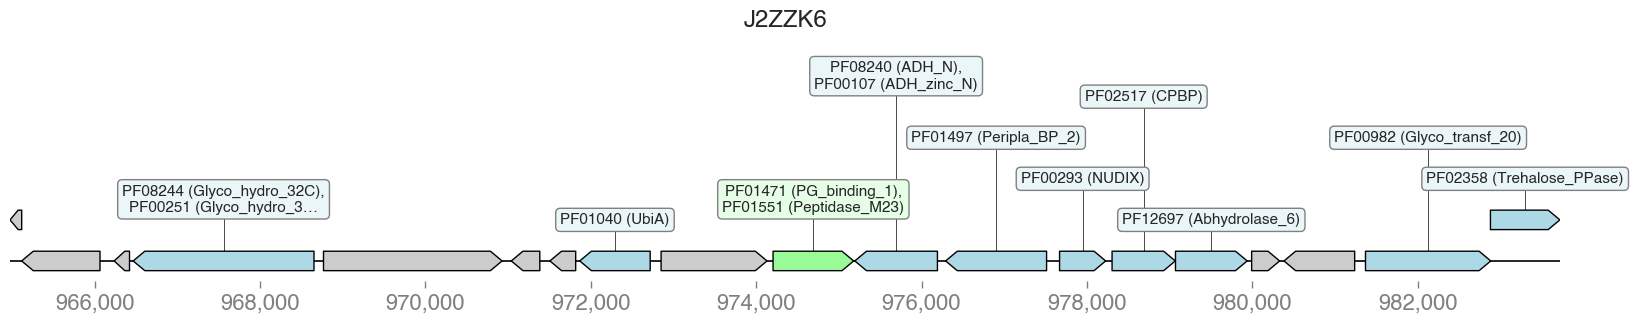

In [20]:
ax = plot_genes(J2ZZK6_df);
ax.set_title('J2ZZK6');
plt.gcf().savefig(figures_folder / 'gene_context' / 'J2ZZK6.pdf', dpi=300, bbox_inches='tight');

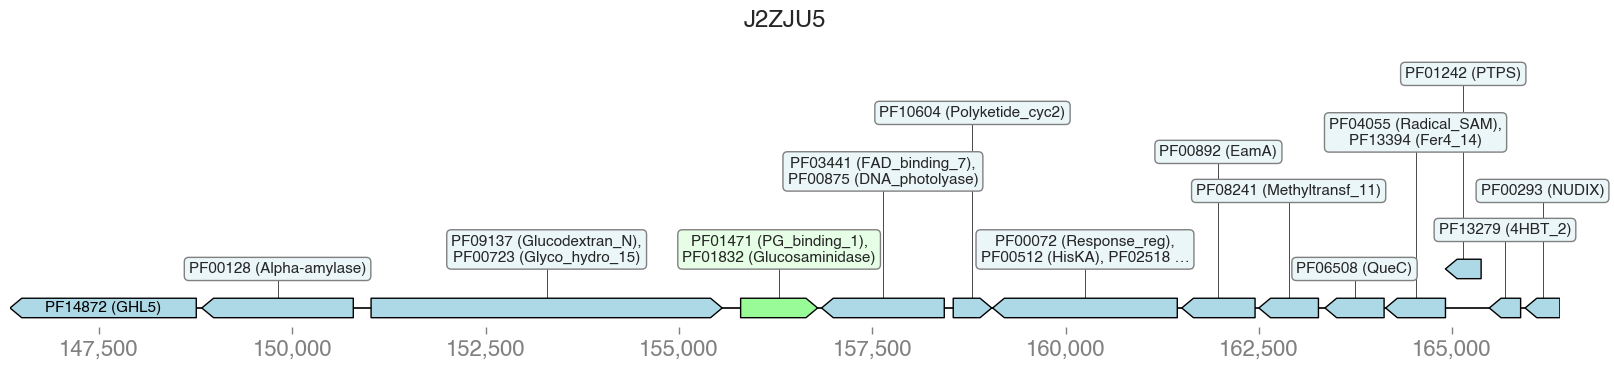

In [19]:
ax = plot_genes(J2ZJU5_df);
ax.set_title('J2ZJU5');
plt.gcf().savefig(figures_folder / 'gene_context' / 'J2ZJU5.pdf', dpi=300, bbox_inches='tight');